## Exp No : 12

## Name : VIJAY K

## Reg No: 212224240182

In [18]:
%pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
%pip install opencv-python==4.10.0.84


Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import sys
!{sys.executable} -m pip install opencv-contrib-python --timeout 120 --retries 5

  Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-win_amd64.whl (53.8 MB)


In [20]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

In [21]:
model = cv2.imread('TMdfyFve.webp',0)
withglass = cv2.imread('images (12)1.jpg',0)
group = cv2.imread('group img.jpg',0)

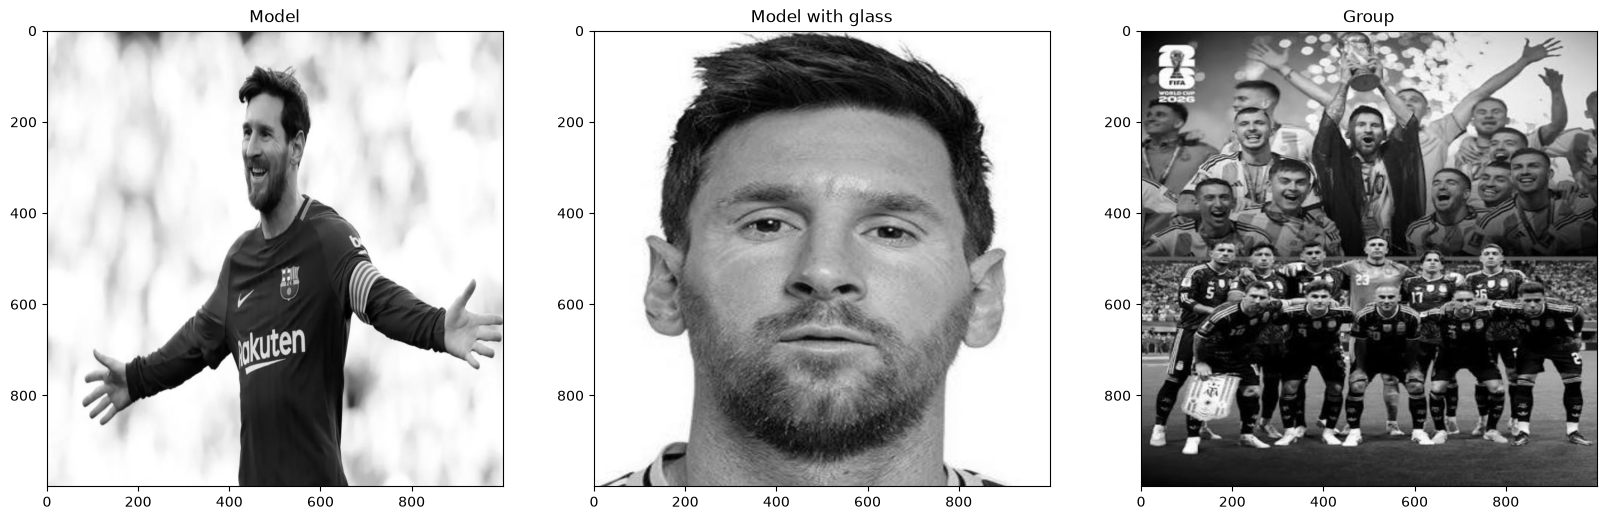

In [22]:
plt.figure(figsize=(20,10))
plt.subplot(131);plt.imshow(cv2.resize(model, (1000, 1000)),cmap='gray');plt.title("Model")
plt.subplot(132);plt.imshow(cv2.resize(withglass, (1000, 1000)),cmap='gray');plt.title("Model with glass")
plt.subplot(133);plt.imshow(cv2.resize(group, (1000, 1000)),cmap='gray');plt.title("Group")
plt.show()

In [23]:
import cv2

print("cv2 file:", cv2.__file__)
print("cv2 version:", getattr(cv2, "__version__", "No version"))
print("CascadeClassifier exists:", hasattr(cv2, "CascadeClassifier"))


cv2 file: C:\Users\admin\anaconda3\envs\opencv\Lib\site-packages\cv2\__init__.py
cv2 version: 4.10.0
CascadeClassifier exists: True


In [24]:
face_cascade_path = "haarcascade_frontalface_default.xml"

face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise RuntimeError(
        f"Face cascade could not be loaded.\nPath: {face_cascade_path}"
    )

print("Face cascade loaded successfully!")
print(face_cascade_path)

Face cascade loaded successfully!
haarcascade_frontalface_default.xml


In [25]:
def detect_face(img):
    face_img = img.copy()

    # Convert to grayscale if the image is colored
    if len(face_img.shape) == 3:
        gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_img

    face_rects = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in face_rects:
        cv2.rectangle(
            face_img,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            3
        )

    return face_img

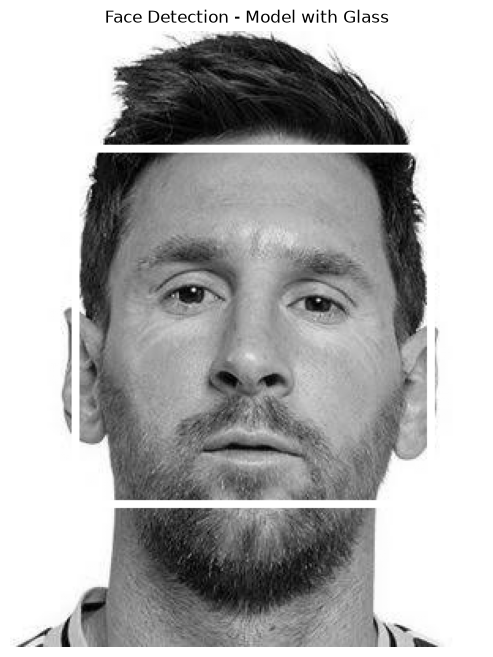

In [26]:
result = detect_face(withglass)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face Detection - Model with Glass")
plt.axis('off')
plt.show()

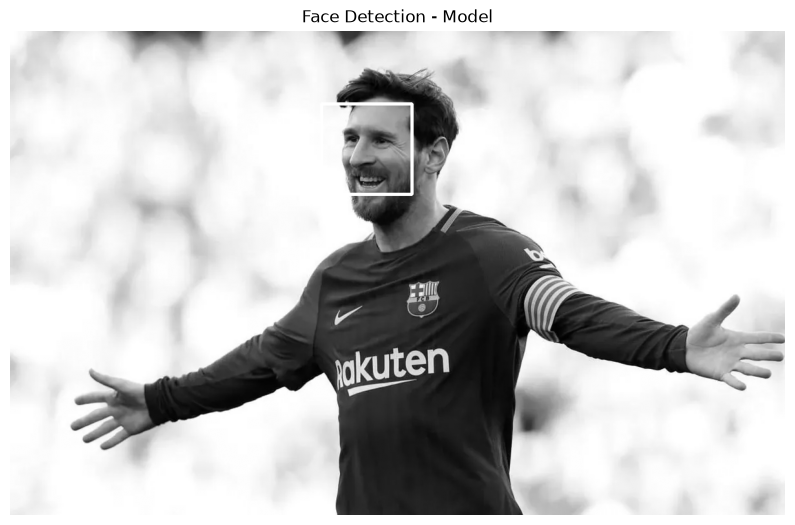

In [27]:
result = detect_face(model)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face Detection - Model")
plt.axis('off')
plt.show()

In [28]:
import cv2

print("OpenCV:", cv2.__version__)
print("Haar folder:", cv2.data.haarcascades)

OpenCV: 4.10.0
Haar folder: C:\Users\admin\anaconda3\envs\opencv\Lib\site-packages\cv2\data\


In [29]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [30]:
face_cascade = cv2.CascadeClassifier(
    r"C:\Users\admin\haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    r"C:\Users\admin\haarcascade_eye.xml"
)

print("Face cascade empty:", face_cascade.empty())
print("Eye cascade empty:", eye_cascade.empty())

Face cascade empty: False
Eye cascade empty: False


In [31]:
def detect_eyes(img):
    face_img = img.copy()

    if len(face_img.shape) == 3:
        gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_img

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(50, 50)
    )

    print("Faces detected:", len(faces))

    for (x, y, w, h) in faces:

        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255, 255, 255), 2)

        # Only upper part of face for eye detection
        roi_gray = gray[y:y+int(h*0.6), x:x+w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.05,
            minNeighbors=4,
            minSize=(15, 15)
        )

        print("Eyes detected:", len(eyes))

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(
                face_img,
                (x + ex, y + ey),
                (x + ex + ew, y + ey + eh),
                (255, 255, 255),
                2
            )

    return face_img

Faces detected: 1
Eyes detected: 2


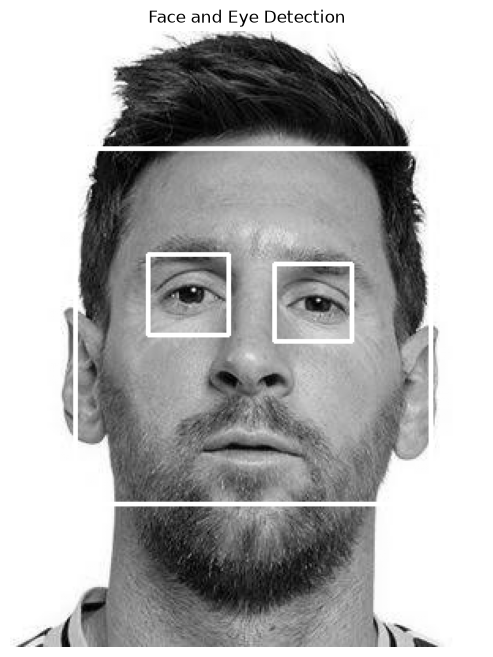

In [32]:
result = detect_eyes(withglass)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face and Eye Detection")
plt.axis('off')
plt.show()

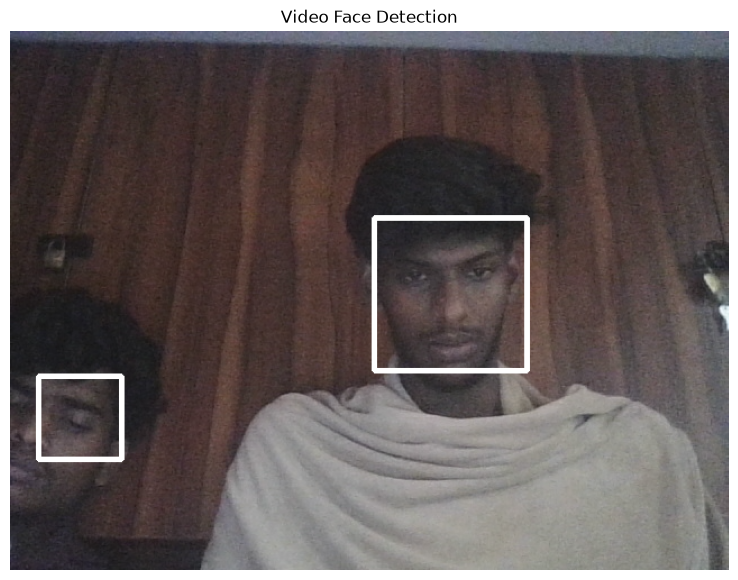

In [33]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open the camera. "
        "Check whether your webcam is connected or being used by another application."
    )

plt.ion()

fig, ax = plt.subplots(figsize=(10, 7))

ret, frame = cap.read()

if not ret:
    cap.release()
    plt.close(fig)
    raise RuntimeError("Could not read the first frame from the camera.")

frame = detect_face(frame)

im = ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax.set_title("Video Face Detection")
ax.axis('off')

while plt.fignum_exists(fig.number):

    ret, frame = cap.read()

    if not ret:
        print("Could not read frame from camera.")
        break

    frame = detect_face(frame)

    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    plt.pause(0.01)

cap.release()
plt.ioff()
plt.close(fig)
